# California Housing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RepeatedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from genbart.reg_bart import RegBart

In [2]:
conf_color = '#227018'
fill_color = '#44f02e'

plt.style.use("bart_style.mplstyle")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Data

In [3]:
data = fetch_california_housing(as_frame=True)
X = data.data.copy()
y = data.target.copy()

display(X.head())
display(y.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [4]:
display(X.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


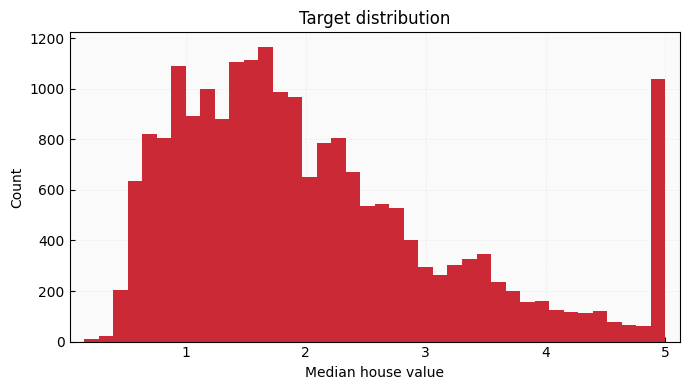

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(y, bins=40)
plt.title("Target distribution")
plt.xlabel("Median house value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Preprocessing

In [6]:
numeric_features = X.columns.tolist()

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    ]
)

In [7]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        )
    ]
)

### Model Definitions

In [8]:
linear_model = Pipeline([
    ("prep", linear_preprocessor),
    ("model", LinearRegression())
])

ridge_model = Pipeline([
    ("prep", linear_preprocessor),
    ("model", Ridge())
])

rf_model = Pipeline([
    ("prep", tree_preprocessor),
    ("model", RandomForestRegressor(random_state=0, n_jobs=-1))
])

hgbm_model = Pipeline([
    ("prep", tree_preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=0))
])

In [9]:
ridge_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

rf_grid = {
    "model__n_estimators": [200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 5, 10]
}

hgbm_grid = {
    "model__learning_rate": [0.03, 0.1],
    "model__max_depth": [None, 5, 10],
    "model__max_leaf_nodes": [15, 31]
}

### Helper Funcitons

In [10]:
def regression_metrics(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

In [11]:
def interval_metrics(y_true, low, high):
    covered = (y_true >= low) & (y_true <= high)
    width = high - low
    return {
        "coverage": np.mean(covered),
        "avg_interval_width": np.mean(width)
    }

In [12]:
def tune_and_evaluate_sklearn_model(model, param_grid, X_train, y_train, X_test, y_test, seed):
    inner_cv = RepeatedKFold(n_splits=3, n_repeats=1, random_state=seed)

    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    metrics = regression_metrics(y_test, y_pred)

    return {
        "best_model": best_model,
        "best_params": search.best_params_,
        "metrics": metrics
    }

In [13]:
def cv_score_bart(X_train, y_train, params, seed, n_burn=100, n_samples=300):
    cv = RepeatedKFold(n_splits=3, n_repeats=1, random_state=seed)
    rmses = []

    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)

    for fold_id, (tr_idx, val_idx) in enumerate(cv.split(X_train)):
        X_tr = X_train[tr_idx]
        y_tr = y_train[tr_idx]
        X_val = X_train[val_idx]
        y_val = y_train[val_idx]

        model = RegBart(
            m=params["m"],
            alpha=0.95,
            beta=2.0,
            k=params["k"],
            nu=params["nu"],
            q=params["q"],
            n_burn=n_burn,
            n_samples=n_samples,
            random_state=seed + fold_id
        )
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val, conf_int=False)["prediction"]

        rmses.append(np.sqrt(mean_squared_error(y_val, pred)))

    return np.mean(rmses)

## Single Split

In [14]:
seed = 0

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed
)

First we fit a linear model to use as a benchmark.

In [15]:
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_metrics = regression_metrics(y_test, linear_pred)
linear_metrics

{'rmse': np.float64(0.7273129773603114),
 'mae': 0.5351261336554506,
 'r2': 0.5943232652466204}

In [16]:
bart_default = RegBart(
    m=200,
    alpha=0.95,
    beta=2.0,
    k=2.0,
    nu=3.0,
    q=0.90,
    n_burn=200,
    n_samples=1000,
    random_state=seed
)

bart_default.fit(X_train.to_numpy(), y_train.to_numpy())

In [17]:
bart_out = bart_default.predict(X_test.to_numpy(), conf_int=True, level=0.90)

bart_metrics = regression_metrics(y_test.to_numpy(), bart_out["prediction"])
bart_metrics

{'rmse': np.float64(0.630097452950471),
 'mae': 0.45699916079078234,
 'r2': 0.6955241323838137}

In [18]:
pred_df = pd.DataFrame({
    "y_true": y_test.to_numpy(),
    "bart_pred": bart_out["prediction"],
    "bart_low": bart_out["conf_int_low"],
    "bart_high": bart_out["conf_int_high"],
    "linear_pred": linear_pred
})

display(pred_df.head())

,y_true,bart_pred,bart_low,bart_high,linear_pred
0,1.369,1.451789,1.104829,1.843475,2.281107
1,2.413,2.734578,2.347147,3.074597,2.790091
2,2.007,1.818987,1.293863,2.337455,1.903328
3,0.725,1.005547,0.321010,1.505192,1.017603
4,4.600,3.366289,2.737680,3.885320,2.948524


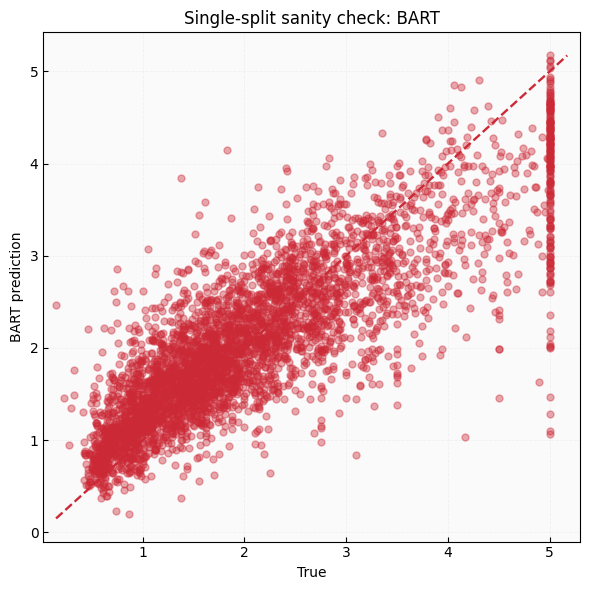

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["y_true"], pred_df["bart_pred"], alpha=0.4)

lims = [
    min(pred_df["y_true"].min(), pred_df["bart_pred"].min()),
    max(pred_df["y_true"].max(), pred_df["bart_pred"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("True")
plt.ylabel("BART prediction")
plt.title("Single-split sanity check: BART")
plt.tight_layout()
plt.show()

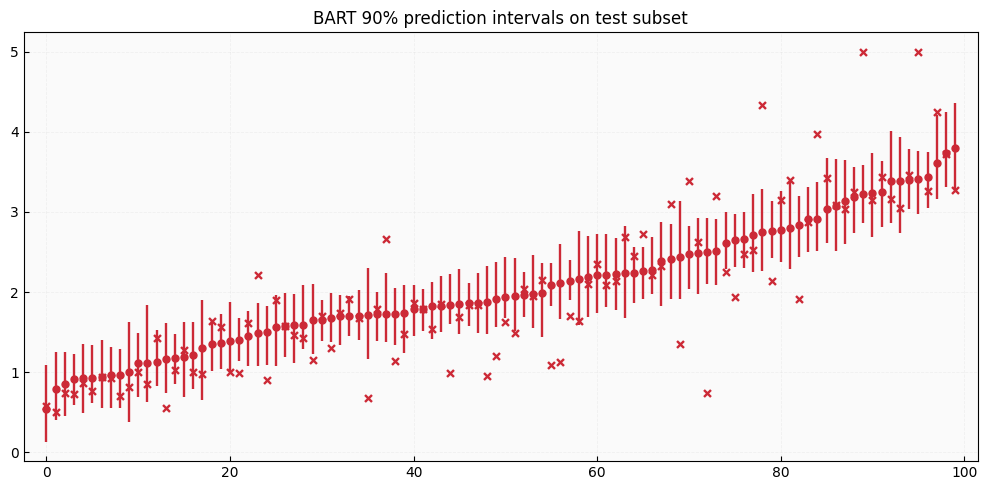

In [20]:
rng = np.random.default_rng(0)
idx = rng.choice(len(pred_df), size=100, replace=False)

sub = pred_df.iloc[idx].copy().sort_values("bart_pred").reset_index(drop=True)

plt.figure(figsize=(10, 5))
x_axis = np.arange(len(sub))

plt.errorbar(
    x_axis,
    sub["bart_pred"],
    yerr=[sub["bart_pred"] - sub["bart_low"], sub["bart_high"] - sub["bart_pred"]],
    fmt="o"
)
plt.scatter(x_axis, sub["y_true"], marker="x")
plt.title("BART 90% prediction intervals on test subset")
plt.tight_layout()
plt.show()

# Comparison

In [22]:
outer_seeds = list(range(10))
results = []
bart_interval_results = []

In [23]:
bart_grid = [
    {"m": 50, "k": 1.0, "nu": 3.0, "q": 0.90},
    {"m": 50, "k": 2.0, "nu": 3.0, "q": 0.90},
    {"m": 200, "k": 1.0, "nu": 3.0, "q": 0.90},
    {"m": 200, "k": 2.0, "nu": 3.0, "q": 0.90},
]

for split_id, seed in enumerate(outer_seeds):
    print(f"Running split {split_id + 1}/{len(outer_seeds)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    # Linear regression
    linear_model.fit(X_train, y_train)
    y_pred = linear_model.predict(X_test)
    results.append({
        "split": split_id,
        "model": "linear_regression",
        **regression_metrics(y_test, y_pred)
    })

    # Ridge
    ridge_out = tune_and_evaluate_sklearn_model(
        ridge_model, ridge_grid, X_train, y_train, X_test, y_test, seed
    )
    results.append({
        "split": split_id,
        "model": "ridge",
        **ridge_out["metrics"],
        "best_params": ridge_out["best_params"]
    })

    # Random forest
    rf_out = tune_and_evaluate_sklearn_model(
        rf_model, rf_grid, X_train, y_train, X_test, y_test, seed
    )
    results.append({
        "split": split_id,
        "model": "random_forest",
        **rf_out["metrics"],
        "best_params": rf_out["best_params"]
    })

    # HistGradientBoosting
    hgbm_out = tune_and_evaluate_sklearn_model(
        hgbm_model, hgbm_grid, X_train, y_train, X_test, y_test, seed
    )
    results.append({
        "split": split_id,
        "model": "hist_gbm",
        **hgbm_out["metrics"],
        "best_params": hgbm_out["best_params"]
    })

    # BART default
    bart_default = RegBart(
        m=200,
        alpha=0.95,
        beta=2.0,
        k=2.0,
        nu=3.0,
        q=0.90,
        n_burn=200,
        n_samples=1000,
        random_state=seed
    )
    bart_default.fit(X_train.to_numpy(), y_train.to_numpy())
    bart_pred = bart_default.predict(X_test.to_numpy(), conf_int=True, level=0.90)

    results.append({
        "split": split_id,
        "model": "bart_default",
        **regression_metrics(y_test.to_numpy(), bart_pred["prediction"])
    })

    bart_interval_results.append({
        "split": split_id,
        "model": "bart_default",
        **interval_metrics(
            y_test.to_numpy(),
            bart_pred["conf_int_low"],
            bart_pred["conf_int_high"]
        )
    })

    # BART tuned
    best_params = None
    best_score = np.inf

    X_train_np = X_train.to_numpy()
    y_train_np = y_train.to_numpy()

    for params in bart_grid:
        score = cv_score_bart(X_train_np, y_train_np, params, seed)
        if score < best_score:
            best_score = score
            best_params = params

    bart_tuned = RegBart(
        m=best_params["m"],
        alpha=0.95,
        beta=2.0,
        k=best_params["k"],
        nu=best_params["nu"],
        q=best_params["q"],
        n_burn=200,
        n_samples=1000,
        random_state=seed
    )
    bart_tuned.fit(X_train_np, y_train_np)
    bart_pred = bart_tuned.predict(X_test.to_numpy(), conf_int=True, level=0.90)

    results.append({
        "split": split_id,
        "model": "bart_tuned",
        **regression_metrics(y_test.to_numpy(), bart_pred["prediction"]),
        "best_params": best_params
    })

    bart_interval_results.append({
        "split": split_id,
        "model": "bart_tuned",
        **interval_metrics(
            y_test.to_numpy(),
            bart_pred["conf_int_low"],
            bart_pred["conf_int_high"]
        )
    })

Running split 1/10


KeyboardInterrupt: 